<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/13_ML_DL_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13 실습: 머신러닝과 딥러닝 기반 시계열의 개요
**Notebook:** `13_ML_DL_Forecasting.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 전통적 시계열 모형과 머신러닝/딥러닝 접근의 차이를 데이터 구조 측면에서 이해합니다.
2. 시계열을 지도학습(supervised learning) 문제로 변환하기 위해 **lag feature / sliding window**를 생성합니다.
3. 시간 순서를 유지한 **train / validation / test split**을 구현합니다.
4. 스케일러를 훈련 데이터에만 적합하여 정보 누수(data leakage)를 방지합니다.
5. Baseline, Linear Regression, Random Forest, MLP, LSTM을 비교합니다.
6. 예측 성능(MAE, RMSE, MAPE)을 비교하고, 실제값과 예측값을 시각화합니다.
7. 트리 기반 모델의 외삽(extrapolation) 한계와 딥러닝 모델의 장단점을 해석합니다.

---

## 왜 이 실습이 중요한가?
전통적인 ARIMA나 SARIMA는 시계열의 자기상관 구조를 직접 모델링합니다.  
반면 일반적인 머신러닝 모델은 시간 순서를 스스로 이해하지 못하므로, 분석가가 **과거 관측값을 입력 변수로 재구성**해 주어야 합니다.

즉, 머신러닝 기반 시계열 예측의 핵심은 다음 두 가지입니다.

1. **데이터를 어떻게 supervised format으로 바꿀 것인가**
2. **시간 순서를 어떻게 보존한 채 학습·검증·평가할 것인가**

이번 실습은 이 두 가지를 중심으로, 간단한 ML/DL 모델을 실제로 돌려 보면서  
예측력, 해석력, 운영성의 차이를 확인하는 데 목적이 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 실습용 시계열 데이터 불러오기
이번 실습에서는 `statsmodels`에 포함된 **CO2 월별 시계열**을 사용합니다.

이 데이터는

- 장기 추세가 존재하고
- 계절성이 반복되며
- 월별 빈도로 정리하기 쉽기 때문에

lag feature와 windowing을 실습하기에 적합합니다.


In [3]:
# ============================================
# 3. CO2 데이터 로드 및 월별 정리
# ============================================

import statsmodels.api as sm

co2 = sm.datasets.co2.load_pandas().data.copy()
co2["co2"] = co2["co2"].interpolate(method="linear")

series = co2["co2"].resample("M").mean().dropna()
series.name = "CO2"

print("Series length:", len(series))
display(series.head())


Series length: 526


,CO2
1958-03-31,316.100
1958-04-30,317.200
1958-05-31,317.410
1958-06-30,316.675
1958-07-31,315.625


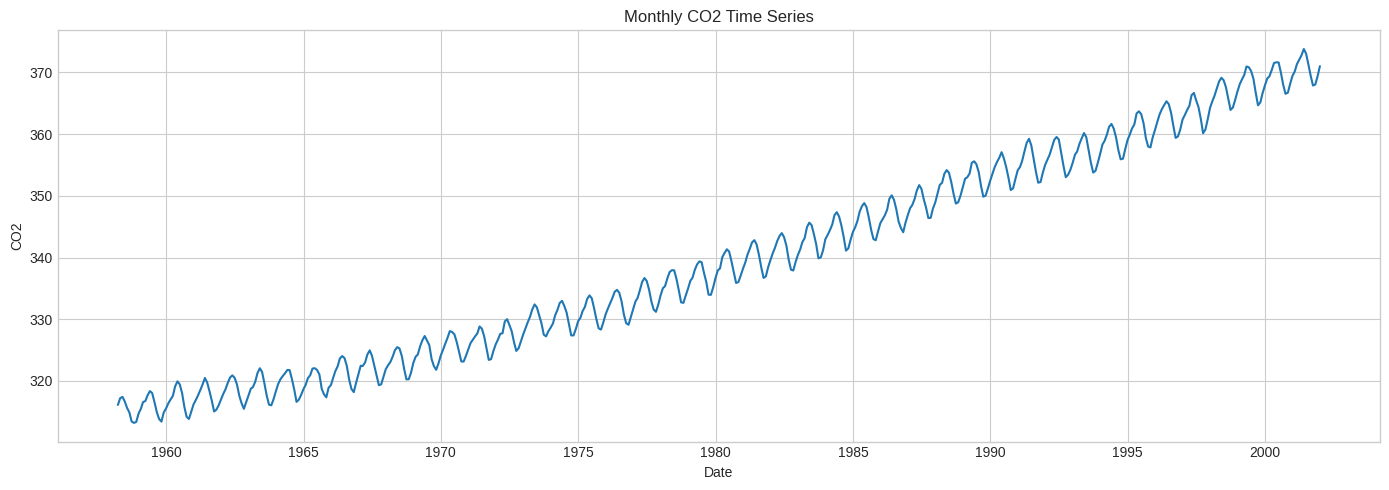

In [4]:
# ============================================
# 4. 원시 시계열 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(series.index, series, linewidth=1.5)

plt.title("Monthly CO2 Time Series")
plt.xlabel("Date")
plt.ylabel("CO2")
plt.tight_layout()
plt.show()


## 3. Baseline: Seasonal Naive
계절성이 있는 월별 데이터에서는 Seasonal Naive가 강력한 기준선이 됩니다.

이번 실습에서는 `t` 시점의 예측값을 `t-12` 시점 값으로 두겠습니다.


In [5]:
# ============================================
# 5. Seasonal naive baseline을 위한 함수
# ============================================

def seasonal_naive_predict(series, seasonal_lag=12):
    return series.shift(seasonal_lag)


## 4. 시계열을 지도학습 형식으로 바꾸기
머신러닝 모델은 기본적으로 표(tabular) 데이터를 입력으로 받습니다.  
따라서 시계열을 다음처럼 바꾸어야 합니다.

- 입력 X: 과거 `window_size`개의 관측값
- 타깃 y: 다음 시점의 관측값

예를 들어 `window_size = 12`이면,  
지난 12개월 값을 사용해 다음 달 값을 예측하는 구조가 됩니다.


In [6]:
# ============================================
# 6. Lag feature / sliding window 생성 함수
# ============================================

def make_supervised(series, window_size=12):
    df = pd.DataFrame({"y": series})
    for lag in range(1, window_size + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)
    df = df.dropna()
    return df

window_size = 12
supervised_df = make_supervised(series, window_size=window_size)

print("Supervised shape:", supervised_df.shape)
display(supervised_df.head())


Supervised shape: (514, 13)


,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
1959-03-31,316.7375,316.5625,315.5000,314.7000,313.351111,313.194444,313.416667,314.870000,315.625000,316.675000,317.410000,317.200,316.100
1959-04-30,317.6750,316.7375,316.5625,315.5000,314.700000,313.351111,313.194444,313.416667,314.870000,315.625000,316.675000,317.410,317.200
1959-05-31,318.3500,317.6750,316.7375,316.5625,315.500000,314.700000,313.351111,313.194444,313.416667,314.870000,315.625000,316.675,317.410
1959-06-30,318.0250,318.3500,317.6750,316.7375,316.562500,315.500000,314.700000,313.351111,313.194444,313.416667,314.870000,315.625,316.675
1959-07-31,316.5250,318.0250,318.3500,317.6750,316.737500,316.562500,315.500000,314.700000,313.351111,313.194444,313.416667,314.870,315.625


## 5. supervised matrix 확인
이제 각 행은 하나의 학습 샘플이 됩니다.

- `lag_1`: 직전 시점
- `lag_2`: 2시점 전
- ...
- `lag_12`: 12시점 전
- `y`: 현재 시점(예측 목표)

이 구조가 머신러닝 기반 시계열 예측의 가장 기본적인 출발점입니다.


In [7]:
# ============================================
# 7. 입력 X와 타깃 y 분리
# ============================================

feature_cols = [c for c in supervised_df.columns if c.startswith("lag_")]
X_all = supervised_df[feature_cols].copy()
y_all = supervised_df["y"].copy()

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)


X shape: (514, 12)
y shape: (514,)


## 6. 시간 순서를 유지한 Train / Validation / Test 분할
시계열에서는 무작위 셔플을 하지 않습니다.  
이번 실습에서는 다음과 같이 나눕니다.

- Train: 70%
- Validation: 15%
- Test: 15%

Validation set은 하이퍼파라미터나 epoch 선택, early stopping 관점에서 중요합니다.


In [8]:
# ============================================
# 8. Train / Validation / Test split
# ============================================

n = len(supervised_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_all.iloc[:train_end].copy()
y_train = y_all.iloc[:train_end].copy()

X_val = X_all.iloc[train_end:val_end].copy()
y_val = y_all.iloc[train_end:val_end].copy()

X_test = X_all.iloc[val_end:].copy()
y_test = y_all.iloc[val_end:].copy()

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 359
Validation size: 77
Test size: 78


## 7. 정보 누수 방지를 위한 스케일링
머신러닝/딥러닝에서는 스케일링이 중요합니다.  
하지만 스케일러를 전체 데이터에 적합하면 미래 정보가 과거 학습에 스며들 수 있습니다.

따라서 반드시

1. Train에만 `fit`
2. Validation/Test에는 `transform`만 수행

해야 합니다.


In [9]:
# ============================================
# 9. 스케일링
# ============================================

from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.to_frame()).ravel()
y_val_scaled = y_scaler.transform(y_val.to_frame()).ravel()
y_test_scaled = y_scaler.transform(y_test.to_frame()).ravel()

print("Scaling complete")


Scaling complete


## 8. 베이스라인 예측 생성
평가 구간은 test set입니다.  
Seasonal Naive는 원래 시계열을 기준으로 `12개월 전 값`을 test index에 맞춰 가져옵니다.


In [10]:
# ============================================
# 10. Test 구간 baseline 생성
# ============================================

baseline_series = seasonal_naive_predict(series, seasonal_lag=12)
baseline_test = baseline_series.loc[y_test.index]

display(pd.DataFrame({
    "Actual": y_test.head(),
    "Seasonal_Naive": baseline_test.head()
}))


,Actual,Seasonal_Naive
1995-07-31,361.800,359.460
1995-08-31,359.375,357.375
1995-09-30,358.000,355.925
1995-10-31,357.850,356.020
1995-11-30,359.475,357.575


## 9. 평가 함수 정의
이번 실습에서는 세 가지 평가 지표를 사용합니다.

- MAE
- RMSE
- MAPE


In [11]:
# ============================================
# 11. 평가 함수
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_value = mape(y_true, y_pred)
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE": [mape_value]
    })


## 10. Model 1: Linear Regression
가장 단순한 머신러닝 기준선으로 선형회귀를 사용합니다.  
이는 lag feature의 선형 결합만으로 예측한다는 점에서, AR 계열 모형과도 일정 부분 직관이 연결됩니다.


In [12]:
# ============================================
# 12. Linear Regression
# ============================================

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled)

lr_val_pred_scaled = lr_model.predict(X_val_scaled)
lr_test_pred_scaled = lr_model.predict(X_test_scaled)

lr_test_pred = y_scaler.inverse_transform(lr_test_pred_scaled.reshape(-1, 1)).ravel()
lr_eval = evaluate_forecast(y_test, lr_test_pred, "Linear Regression")
display(lr_eval)


,Model,MAE,RMSE,MAPE
0,Linear Regression,0.415879,0.529193,0.113441


## 11. Model 2: Random Forest
트리 기반 모델은 변수 간 비선형 관계와 상호작용을 잘 포착할 수 있습니다.  
그러나 시계열에서 강한 추세가 있을 경우, 훈련 범위 밖으로 외삽(extrapolation)하는 데 약할 수 있습니다.


In [13]:
# ============================================
# 13. Random Forest
# ============================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train_scaled)
rf_test_pred_scaled = rf_model.predict(X_test_scaled)

rf_test_pred = y_scaler.inverse_transform(rf_test_pred_scaled.reshape(-1, 1)).ravel()
rf_eval = evaluate_forecast(y_test, rf_test_pred, "Random Forest")
display(rf_eval)


,Model,MAE,RMSE,MAPE
0,Random Forest,12.824147,13.403932,3.489789


## 12. Model 3: MLP Regressor
MLP는 입력층과 출력층 사이에 은닉층(hidden layer)을 가진 기본적인 feedforward neural network입니다.  
딥러닝의 복잡한 구조에 들어가기 전에, 비선형 신경망의 가장 기본 형태를 실습하는 데 적합합니다.


In [14]:
# ============================================
# 14. MLP Regressor
# ============================================

from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=800,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train_scaled)
mlp_test_pred_scaled = mlp_model.predict(X_test_scaled)

mlp_test_pred = y_scaler.inverse_transform(mlp_test_pred_scaled.reshape(-1, 1)).ravel()
mlp_eval = evaluate_forecast(y_test, mlp_test_pred, "MLP")
display(mlp_eval)


,Model,MAE,RMSE,MAPE
0,MLP,0.578838,0.734813,0.157882


## 13. Model 4: LSTM
이제 딥러닝 시계열 모델의 대표 예시로 LSTM을 사용합니다.  
LSTM은 순차 데이터를 3차원 텐서 형태로 입력받습니다.

즉, MLP/트리 모델이 `(samples, features)` 구조를 쓰는 반면,  
LSTM은 `(samples, time_steps, features)` 구조를 사용합니다.


In [15]:
# ============================================
# 15. TensorFlow / Keras 준비
# ============================================

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    print("TensorFlow is already installed.")
except ImportError:
    print("TensorFlow is not installed. Installing now...")
    !pip -q install tensorflow
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    print("TensorFlow installation completed.")

tf.random.set_seed(42)
np.random.seed(42)


TensorFlow is already installed.


In [16]:
# ============================================
# 16. LSTM 입력 형태로 변환
# ============================================
# 현재 X는 (samples, lag_features) 구조입니다.
# 이를 (samples, time_steps, 1) 구조로 바꿉니다.
# ============================================

X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("LSTM train shape:", X_train_lstm.shape)
print("LSTM val shape:", X_val_lstm.shape)
print("LSTM test shape:", X_test_lstm.shape)


LSTM train shape: (359, 12, 1)
LSTM val shape: (77, 12, 1)
LSTM test shape: (78, 12, 1)


In [17]:
# ============================================
# 17. LSTM 모형 구성 및 학습
# ============================================

lstm_model = Sequential([
    LSTM(32, input_shape=(X_train_lstm.shape[1], 1)),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm, y_train_scaled,
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=80,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print("Best validation loss:", np.min(history.history["val_loss"]))


Best validation loss: 0.012799966149032116


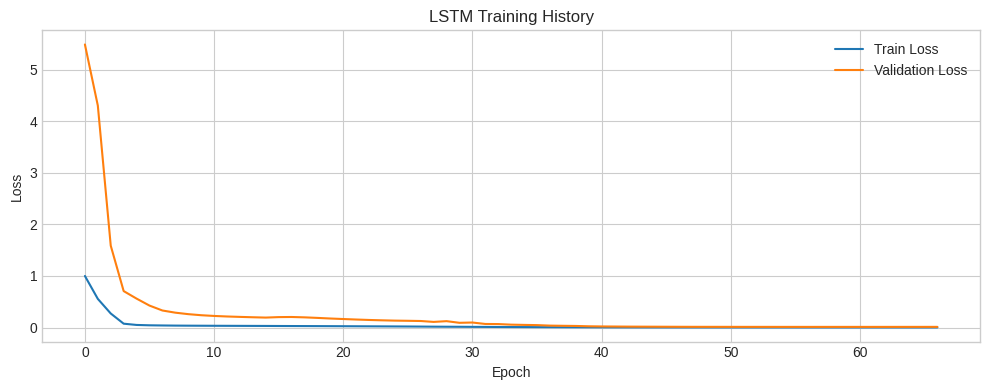

In [18]:
# ============================================
# 18. LSTM 학습 곡선
# ============================================

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# ============================================
# 19. LSTM 테스트 예측
# ============================================

lstm_test_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0).ravel()
lstm_test_pred = y_scaler.inverse_transform(lstm_test_pred_scaled.reshape(-1, 1)).ravel()

lstm_eval = evaluate_forecast(y_test, lstm_test_pred, "LSTM")
display(lstm_eval)


,Model,MAE,RMSE,MAPE
0,LSTM,4.400422,4.969056,1.194766


## 14. 모든 모델 성능 비교
이제 baseline, Linear Regression, Random Forest, MLP, LSTM을 한 표에서 비교합니다.


In [20]:
# ============================================
# 20. 성능 비교표
# ============================================

baseline_eval = evaluate_forecast(y_test, baseline_test, "Seasonal Naive")

all_eval = pd.concat([
    baseline_eval,
    lr_eval,
    rf_eval,
    mlp_eval,
    lstm_eval
], ignore_index=True).sort_values("MAPE")

display(all_eval)


,Model,MAE,RMSE,MAPE
1,Linear Regression,0.415879,0.529193,0.113441
3,MLP,0.578838,0.734813,0.157882
0,Seasonal Naive,1.692885,1.848572,0.462344
4,LSTM,4.400422,4.969056,1.194766
2,Random Forest,12.824147,13.403932,3.489789


## 15. 실제값 vs 예측값 비교
이제 테스트 구간에서 실제값과 각 모델의 예측값을 한 그래프에 비교합니다.


In [21]:
# ============================================
# 21. 예측값 정리
# ============================================

pred_df = pd.DataFrame({
    "Actual": y_test,
    "Seasonal_Naive": baseline_test,
    "Linear_Regression": lr_test_pred,
    "Random_Forest": rf_test_pred,
    "MLP": mlp_test_pred,
    "LSTM": lstm_test_pred
})

display(pred_df.head())


,Actual,Seasonal_Naive,Linear_Regression,Random_Forest,MLP,LSTM
1995-07-31,361.800,359.460,361.549054,353.500853,360.980674,359.107697
1995-08-31,359.375,357.375,359.739021,353.500853,359.508854,358.423004
1995-09-30,358.000,355.925,358.112525,353.500853,357.884160,358.044678
1995-10-31,357.850,356.020,358.215498,353.500853,357.997572,358.320221
1995-11-30,359.475,357.575,359.299203,353.500853,359.428040,359.044159


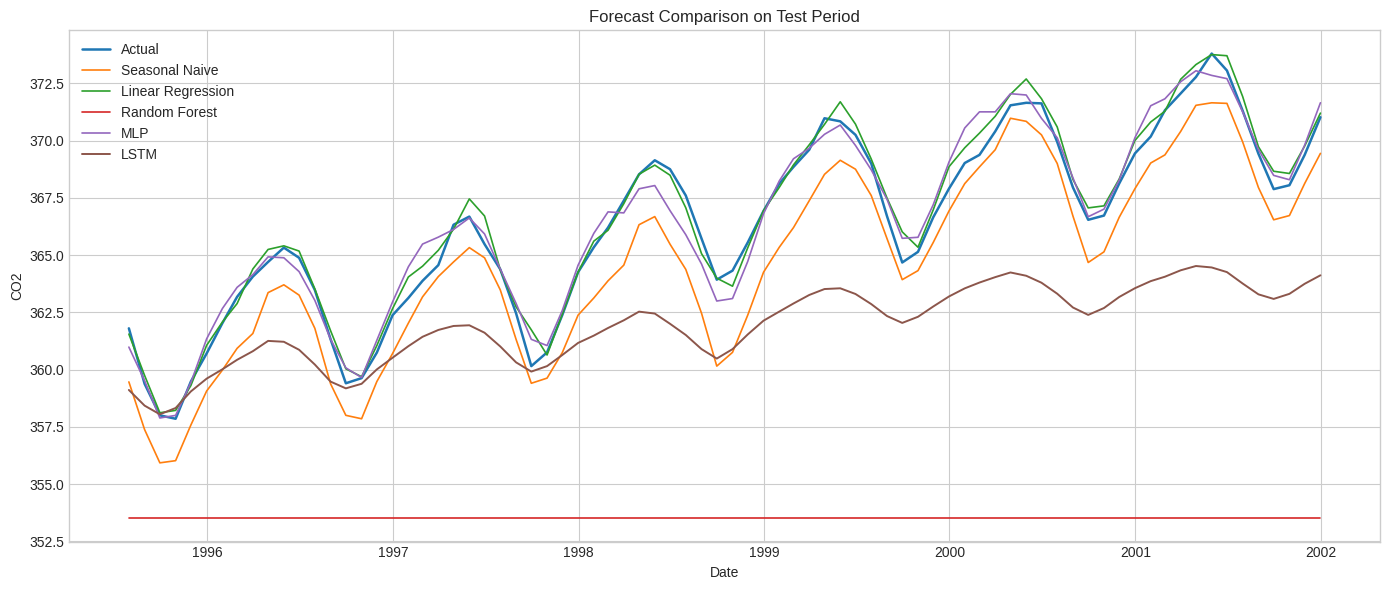

In [22]:
# ============================================
# 22. 테스트 구간 비교 플롯
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(pred_df.index, pred_df["Actual"], label="Actual", linewidth=1.8)
plt.plot(pred_df.index, pred_df["Seasonal_Naive"], label="Seasonal Naive", linewidth=1.2)
plt.plot(pred_df.index, pred_df["Linear_Regression"], label="Linear Regression", linewidth=1.2)
plt.plot(pred_df.index, pred_df["Random_Forest"], label="Random Forest", linewidth=1.2)
plt.plot(pred_df.index, pred_df["MLP"], label="MLP", linewidth=1.2)
plt.plot(pred_df.index, pred_df["LSTM"], label="LSTM", linewidth=1.4)

plt.title("Forecast Comparison on Test Period")
plt.xlabel("Date")
plt.ylabel("CO2")
plt.legend()
plt.tight_layout()
plt.show()


## 16. Random Forest의 외삽 한계 직관
트리 기반 모델은 관측된 입력-출력 범위 안에서는 강력할 수 있지만,  
강한 추세가 존재할 때 훈련 구간 바깥으로 자연스럽게 외삽하는 데 한계가 있을 수 있습니다.

따라서 시계열에서 트리 모델이 항상 딥러닝이나 선형모형보다 우월하다고 볼 수는 없습니다.  
특히 장기적 상승 추세가 강한 데이터에서는 예측선이 상대적으로 평평해질 수 있습니다.


## 17. 해석 포인트
이번 실습의 결과를 해석할 때 중요한 질문은 다음과 같습니다.

- Seasonal Naive보다 복잡한 모델이 정말 나은가?
- Linear Regression만으로도 충분한가, 아니면 비선형 모델이 필요한가?
- Random Forest는 변동을 잘 잡지만 추세 외삽에는 약한가?
- MLP와 LSTM 중 어느 쪽이 더 안정적인가?
- Validation set 없이 바로 test만 보면 어떤 위험이 있는가?

즉, ML/DL 시계열 모델링의 핵심은 단순 성능 경쟁이 아니라,  
**데이터 구조에 맞는 모델 선택과 올바른 평가 설계**에 있습니다.


## 18. 자주 발생하는 실수 (Common Mistakes)
이번 장에서 특히 자주 발생하는 실수는 다음과 같습니다.

1. **시계열을 그대로 머신러닝 모델에 넣는 실수**  
   lag feature나 sliding window 없이 모델이 시간을 이해할 것이라고 기대하면 안 됩니다.

2. **무작위 train/test split을 사용하는 실수**  
   시계열에서는 shuffle이 곧 정보 누수입니다.

3. **스케일러를 전체 데이터에 fit하는 실수**  
   미래 정보가 훈련 과정에 스며들 수 있습니다.

4. **Validation set 없이 test만 보는 실수**  
   하이퍼파라미터 조정이 test에 오염될 수 있습니다.

5. **복잡한 DL 모델이 항상 더 좋다고 생각하는 실수**  
   데이터 크기, 잡음 수준, 구조에 따라 단순 모델이 더 안정적일 수 있습니다.


## 19. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 머신러닝 기반 시계열 예측은 시계열을 supervised learning 형식으로 재구성하는 데서 시작한다.
- lag feature와 sliding window는 가장 기본적인 데이터 변환 도구이다.
- train / validation / test split은 시간 순서를 유지해야 한다.
- baseline 비교 없이는 복잡한 모델의 실질적 가치를 판단하기 어렵다.
- 트리 기반 모델은 비선형 상호작용을 잘 잡지만 외삽에 약할 수 있다.
- LSTM은 순차 구조를 직접 다루지만, 데이터 양과 학습 설정에 민감하다.
- 좋은 ML/DL 시계열 분석은 모델보다 먼저 **평가 설계와 정보 누수 방지**가 중요하다.


## 20. 연습문제 (Exercises)

1. `window_size`를 6, 12, 24로 바꾸어 성능이 어떻게 달라지는지 비교하시오.

2. Random Forest의 `max_depth`를 바꾸었을 때 과적합 여부를 validation 성능으로 점검하시오.

3. LSTM의 epoch 수나 hidden unit 수를 바꾸었을 때 validation loss와 test 성능이 어떻게 변하는지 비교하시오.

4. CO2 대신 다른 계절 시계열을 사용하여 같은 파이프라인을 반복하시오.

5. 트리 기반 모델이 강한 추세 데이터에서 왜 외삽에 약할 수 있는지 자신의 언어로 설명하시오.
